### Анализ эффективности различных диет

1. Влияет ли пол пациента на значение веса после эксперимента?
2. Влияет ли тип диеты (A,B,C) на значение веса после эксперимента?
3. Есть ли эффект взаимодействия между полом пациента и типом диеты? Например, более сильное влияние определенного типа диеты только на женщин.

In [ ]:
import pandas as pd
import seaborn as sns
from scipy import stats
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [2]:
data = pd.read_csv('data/diet.csv')
data.head()

,gender,diet,preweight,weight6weeks
0,M,B,60,60.0
1,M,B,103,103.0
2,F,A,58,54.2
3,F,A,60,54.0
4,F,A,64,63.3


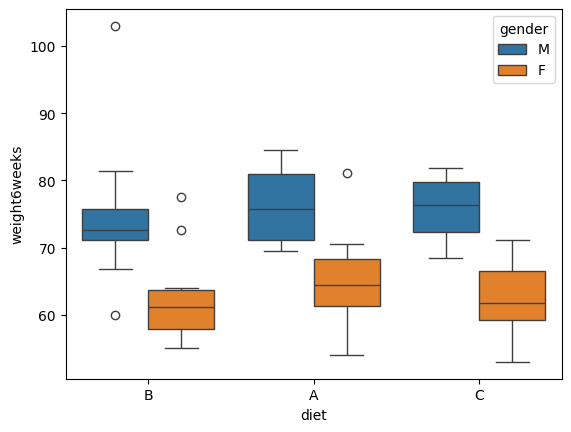

In [3]:
sns.boxplot(data=data, x='diet', y='weight6weeks', hue='gender');

Кажется, что по типу диеты особых различий нет

### One-way ANOVA

<b>Шаг 1. Постановка гипотез:</b>
    
$H_0$: среднее значение веса после окончания эксперимента у мужчин и женщин равны.

$H_1$: среднее значение веса после окончания эксперимента у мужчин и женщин различаются.

<b>Шаг 2. Выбор уровня значимости:</b>
$$\alpha = 0.05$$

<b>Шаг 3. Проведение дисперсионного анализа:</b>

In [4]:
sample_f = data[data.gender == 'F'].weight6weeks
sample_m = data[data.gender == 'M'].weight6weeks

In [5]:
stats.f_oneway(sample_f, sample_m)

F_onewayResult(statistic=np.float64(66.16218641135315), pvalue=np.float64(6.097208570818812e-12))

Можем сказать, что пол человека оказывает существенное влияние на итоговый вес

In [6]:
model = ols('weight6weeks ~ gender', data).fit()
anova_lm(model)

,df,sum_sq,mean_sq,F,PR(>F)
gender,1.0,2854.201553,2854.201553,66.162186,6.097209e-12
Residual,76.0,3278.599601,43.139468,NaN,NaN


<b>Шаг 4. Проверка применимости метода:</b>
- Нормальность распределения факторов или остатков.
- Гомоскедастичность (дисперсия внутри каждой группы должна быть примерно одинаковой).

In [7]:
stats.shapiro(model.resid)

ShapiroResult(statistic=np.float64(0.9333086171627877), pvalue=np.float64(0.0005136699193614193))

Остатки не распределены нормально

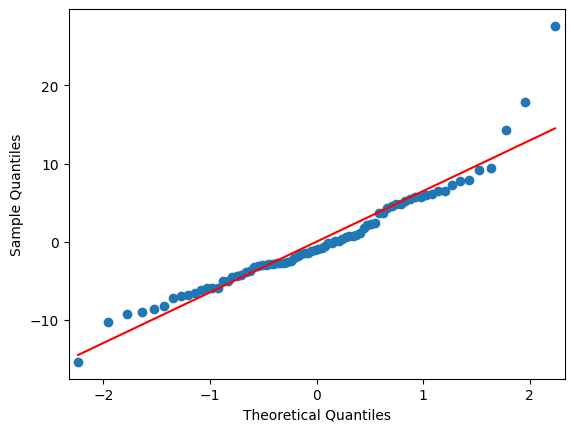

In [8]:
sm.qqplot(model.resid, line='s');

In [9]:
stats.bartlett(sample_f, sample_m)

BartlettResult(statistic=np.float64(0.6939274163080743), pvalue=np.float64(0.40483172475647555))

Диссперсии равны

2. Влияет ли тип диеты (А/В/С), которой придерживается пациент, на значение веса после эксперимента?

In [10]:
model = ols('weight6weeks ~ diet', data).fit()
anova_lm(model)

,df,sum_sq,mean_sq,F,PR(>F)
diet,2.0,29.841339,14.920670,0.183362,0.832839
Residual,75.0,6102.959815,81.372798,NaN,NaN


Тип диеты не оказывает статистически значимого влияния на вес после эксперимента

### Two-way ANOVA

<b>Шаг 1. Постановка гипотез:</b>
    
$H_0$: среднее значение веса после окончания эксперимента у групп мужчин и женщин с различными типами диет(А/В/С) одинаково.

$H_1$: среднее значение веса после окончания эксперимента у групп мужчин и женщин с различными типами диет(А/В/С) различаются.

<b>Шаг 2. Выбор уровня значимости:</b>
$$\alpha = 0.05$$

<b>Шаг 3. Проведение дисперсионного анализа:</b>

In [11]:
model = ols('weight6weeks ~ diet + gender + diet:gender', data).fit()
anova_lm(model)

,df,sum_sq,mean_sq,F,PR(>F)
diet,2.0,29.841339,14.920670,0.335607,7.160162e-01
gender,1.0,2891.375733,2891.375733,65.035052,1.162414e-11
diet:gender,2.0,10.555631,5.277816,0.118713,8.882364e-01
Residual,72.0,3201.028451,44.458728,NaN,NaN


<b>Шаг 4. Проверка применимости метода:</b>
- Нормальность распределения факторов или остатков.
- Гомоскедастичность (дисперсия внутри каждой группы должна быть примерно одинаковой).

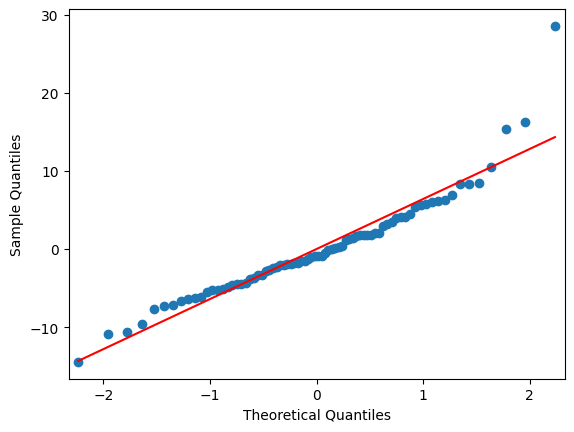

In [12]:
sm.qqplot(model.resid, line='s');

In [13]:
sample_a_f = data[(data.diet == 'A') & (data.gender == 'F')].weight6weeks
sample_b_f = data[(data.diet == 'B') & (data.gender == 'F')].weight6weeks
sample_c_f = data[(data.diet == 'C') & (data.gender == 'F')].weight6weeks

sample_a_m = data[(data.diet == 'A') & (data.gender == 'M')].weight6weeks
sample_b_m = data[(data.diet == 'B') & (data.gender == 'M')].weight6weeks
sample_c_m = data[(data.diet == 'C') & (data.gender == 'M')].weight6weeks

In [14]:
stats.bartlett(sample_a_f, sample_b_f, sample_c_f, sample_a_m, sample_b_m, sample_c_m)

BartlettResult(statistic=np.float64(9.54750655147314), pvalue=np.float64(0.0891199350014268))

Диссперсии равны